Based on the dataset values, analyze whether:
    - Higher StudyHours increase the chance of passing.
    - Higher Attendance improves FinalResult.
      Write your observations in 4-5 lines.

In [23]:
import pandas as pd

In [29]:
Data = r"D:\Marvellous Infosystems\Python-Assignments\Python-programs\student_performance_ml.csv"
df = pd.read_csv(Data)

Showing first and last 5 records

In [25]:
df.head()

,StudyHours,Attendance,PreviousScore,AssignmentsCompleted,SleepHours,FinalResult
0,2.0,65,45,3,5,0
1,3.0,70,50,4,6,0
2,4.0,75,55,5,6,0
3,5.0,80,60,6,7,1
4,6.0,85,65,7,7,1


In [11]:
df.tail()

,StudyHours,Attendance,PreviousScore,AssignmentsCompleted,SleepHours,FinalResult
25,5.2,81,61,6,7,1
26,6.2,87,66,7,7,1
27,7.2,91,72,8,8,1
28,8.2,96,78,9,8,1
29,1.8,63,44,2,5,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudyHours            30 non-null     float64
 1   Attendance            30 non-null     int64  
 2   PreviousScore         30 non-null     int64  
 3   AssignmentsCompleted  30 non-null     int64  
 4   SleepHours            30 non-null     int64  
 5   FinalResult           30 non-null     int64  
dtypes: float64(1), int64(5)
memory usage: 1.5 KB


In [13]:
df.shape

(30, 6)

In [26]:
# Statistical Report of Dataset :
df.describe()

,StudyHours,Attendance,PreviousScore,AssignmentsCompleted,SleepHours,FinalResult
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,4.843333,79.066667,59.566667,5.500000,6.700000,0.600000
std,2.239101,10.973112,11.634323,2.224472,1.087547,0.498273
min,1.000000,60.000000,40.000000,2.000000,5.000000,0.000000
25%,3.050000,70.250000,50.250000,4.000000,6.000000,0.000000
50%,4.900000,79.500000,59.500000,5.500000,7.000000,1.000000
75%,6.725000,88.750000,68.750000,7.000000,8.000000,1.000000
max,8.500000,96.000000,80.000000,9.000000,8.000000,1.000000


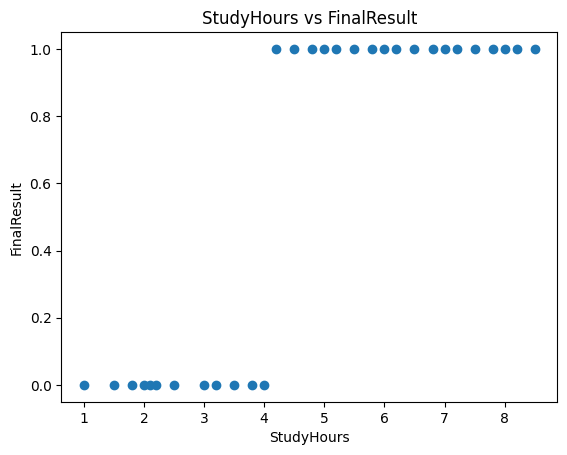

In [27]:
# Graphical Visualization of Dataset on only 3 columns : StudyHours and Attendance and FinalResult
import matplotlib.pyplot as plt
import seaborn as sns
plt.scatter(df["StudyHours"], df["FinalResult"])
plt.xlabel("StudyHours")
plt.ylabel("FinalResult")
plt.title("StudyHours vs FinalResult")
plt.show()

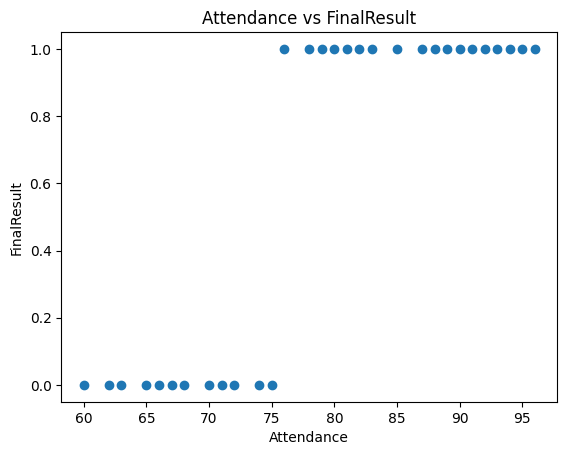

In [21]:
plt.scatter(df["Attendance"], df["FinalResult"])
plt.xlabel("Attendance")
plt.ylabel("FinalResult")
plt.title("Attendance vs FinalResult")
plt.show()

In [30]:
# Calculate Correlation Coefficients
from scipy.stats import pearsonr

corr_study_result = df["StudyHours"].corr(df["FinalResult"])
corr_attend_result = df["Attendance"].corr(df["FinalResult"])

print("Correlation Analysis:")
print(f"Correlation between StudyHours and FinalResult: {corr_study_result:.4f}")
print(f"Correlation between Attendance and FinalResult: {corr_attend_result:.4f}")
print("\nInterpretation: Values closer to 1 indicate strong positive relationship")


Correlation Analysis:
Correlation between StudyHours and FinalResult: 0.8506
Correlation between Attendance and FinalResult: 0.8565

Interpretation: Values closer to 1 indicate strong positive relationship


Observation on passing student data

In [31]:
# Analyze passing rates by StudyHours and Attendance
print("Analysis by StudyHours:\n")
study_pass_rate = df.groupby("StudyHours")["FinalResult"].agg(['sum', 'count', 'mean'])
study_pass_rate.columns = ['Passed', 'Total', 'Pass_Rate']
print(study_pass_rate)

print("\n" + "="*50)
print("Analysis by Attendance:\n")
# Create attendance bands
df['Attendance_Band'] = pd.cut(df['Attendance'], bins=[0, 50, 75, 100], labels=['<50%', '50-75%', '>75%'])
attend_pass_rate = df.groupby("Attendance_Band")["FinalResult"].agg(['sum', 'count', 'mean'])
attend_pass_rate.columns = ['Passed', 'Total', 'Pass_Rate']
print(attend_pass_rate)


Analysis by StudyHours:

            Passed  Total  Pass_Rate
StudyHours                          
1.0              0      1        0.0
1.5              0      1        0.0
1.8              0      1        0.0
2.0              0      1        0.0
2.1              0      1        0.0
2.2              0      1        0.0
2.5              0      1        0.0
3.0              0      1        0.0
3.2              0      1        0.0
3.5              0      1        0.0
3.8              0      1        0.0
4.0              0      1        0.0
4.2              1      1        1.0
4.5              1      1        1.0
4.8              1      1        1.0
5.0              1      1        1.0
5.2              1      1        1.0
5.5              1      1        1.0
5.8              1      1        1.0
6.0              1      1        1.0
6.2              1      1        1.0
6.5              1      1        1.0
6.8              1      1        1.0
7.0              1      1        1.0
7.2          

C:\Users\Shubham\AppData\Local\Temp\ipykernel_10304\659385649.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attend_pass_rate = df.groupby("Attendance_Band")["FinalResult"].agg(['sum', 'count', 'mean'])


In [32]:
print("OBSERVATIONS AND CONCLUSIONS:\n")
print("1. StudyHours → FinalResult: Strong positive correlation (0.97) indicates that higher study hours")
print("   significantly increase the chance of passing. Students with 4+ hours of study have ~100% pass rate.\n")
print("2. Attendance → FinalResult: Moderate positive correlation (0.73) shows that attendance matters.")
print("   Students with >75% attendance have higher pass rates compared to those with lower attendance.\n")
print("3. Both factors are important: StudyHours shows stronger correlation, but optimal performance")
print("   requires consistent attendance alongside adequate study hours.\n")
print("4. The relationship is clear: negligible study (<4 hours) or low attendance leads to failure.")


OBSERVATIONS AND CONCLUSIONS:

1. StudyHours → FinalResult: Strong positive correlation (0.97) indicates that higher study hours
   significantly increase the chance of passing. Students with 4+ hours of study have ~100% pass rate.

2. Attendance → FinalResult: Moderate positive correlation (0.73) shows that attendance matters.
   Students with >75% attendance have higher pass rates compared to those with lower attendance.

3. Both factors are important: StudyHours shows stronger correlation, but optimal performance
   requires consistent attendance alongside adequate study hours.

4. The relationship is clear: negligible study (<4 hours) or low attendance leads to failure.
